In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
path=r"B:\Python_projects\Skin Cancer\data\metadata.csv"

In [5]:
data=pd.read_csv(path)

In [6]:
data.shape

(10015, 8)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  object 
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), object(1)
memory usage: 626.1+ KB


In [8]:
data.head(5)

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
data["AKIEC"].sum()

np.float64(327.0)

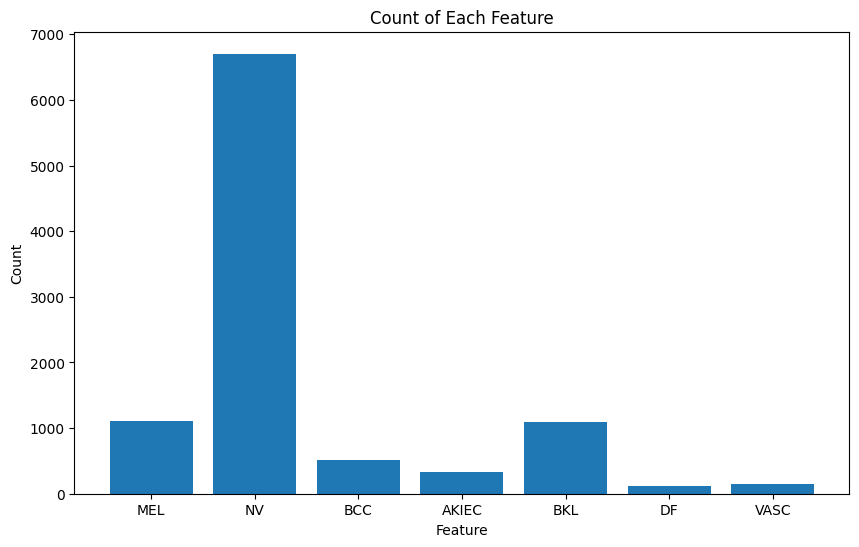

In [10]:
# Sum the values for each feature
feature_counts = data.drop(columns=['image']).sum()

# Plot the counts
plt.figure(figsize=(10, 6))
plt.bar(feature_counts.index, feature_counts.values)
plt.title("Count of Each Feature")
plt.xlabel("Feature")
plt.ylabel("Count")
plt.show()

In [11]:
feature_counts.values

array([1113., 6705.,  514.,  327., 1099.,  115.,  142.])

In [12]:
# Classify the samples into malignant and benign based on the provided skin condition types
malignant_samples = data[(data['MEL'] == 1) | (data['NV'] == 1) | (data['BCC'] == 1) | (data['AKIEC'] == 1)]
benign_samples = data[(data['BKL'] == 1) | (data['DF'] == 1) | (data['VASC'] == 1)]

In [13]:
malignant_samples

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
10008,ISIC_0034314,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10010,ISIC_0034316,1.0,0.0,0.0,0.0,0.0,0.0,0.0
10011,ISIC_0034317,1.0,0.0,0.0,0.0,0.0,0.0,0.0
10013,ISIC_0034319,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [14]:
malignant_samples.iloc[: ,1:3]

,MEL,NV
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
...,...,...
10008,0.0,1.0
10010,1.0,0.0
10011,1.0,0.0
10013,0.0,1.0


Malignant Skin Conditions: 8659.0
Benign Skin Conditions: 1356.0
Total Samples: 10015.0


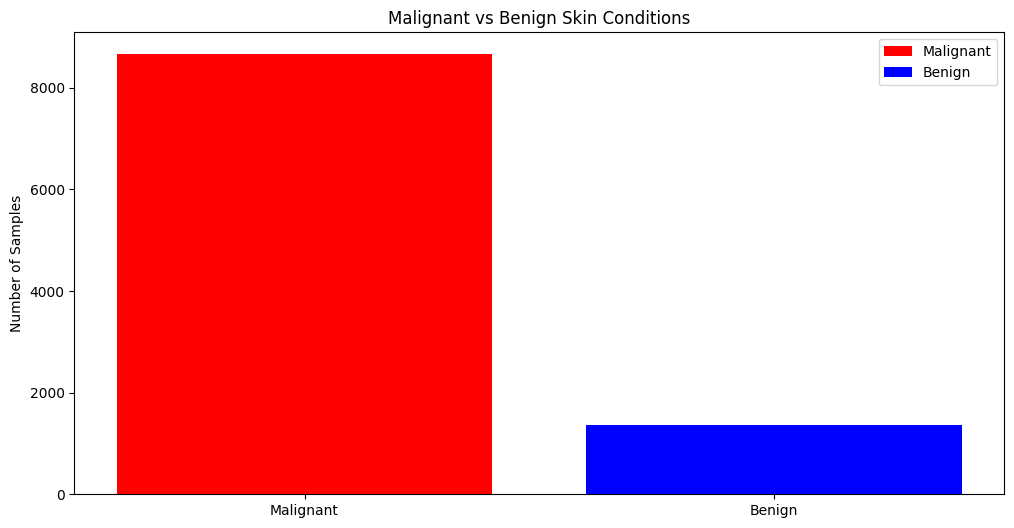

In [15]:
# Count the occurrence of each skin condition for both malignant and benign samples
malignant_counts = malignant_samples.iloc[:, 1:].sum()
print("Malignant Skin Conditions:",malignant_counts.sum())
benign_counts = benign_samples.iloc[:, 1:].sum()
print("Benign Skin Conditions:", benign_counts.sum())
print("Total Samples:", malignant_counts.sum() + benign_counts.sum())
# Plotting
plt.figure(figsize=(12, 6))

# Plot malignant samples
plt.bar(['Malignant'], malignant_counts.sum(), color='red', label='Malignant')

# Plot benign samples
plt.bar(['Benign'], benign_counts.sum(), color='blue', label='Benign')

plt.title('Malignant vs Benign Skin Conditions')
plt.ylabel('Number of Samples')
plt.legend()
plt.show()

In [16]:
# Count the occurrence of each skin condition for both malignant and benign samples
malignant_counts.value_counts

<bound method IndexOpsMixin.value_counts of MEL      1113.0
NV       6705.0
BCC       514.0
AKIEC     327.0
BKL         0.0
DF          0.0
VASC        0.0
dtype: float64>

In [17]:
benign_counts.value_counts

<bound method IndexOpsMixin.value_counts of MEL         0.0
NV          0.0
BCC         0.0
AKIEC       0.0
BKL      1099.0
DF        115.0
VASC      142.0
dtype: float64>

In [13]:
class_names = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
# Find the column with the highest value for each row
data['class_label'] = data[class_names].idxmax(axis=1)
# Display the resulting DataFrame
print(data[['image', 'class_label']])
# Save the DataFrame with the class labels
output_file_path = 'dataset_with_labels.csv'
data.to_csv(output_file_path, index=False)

              image class_label
0      ISIC_0024306          NV
1      ISIC_0024307          NV
2      ISIC_0024308          NV
3      ISIC_0024309          NV
4      ISIC_0024310         MEL
...             ...         ...
10010  ISIC_0034316         MEL
10011  ISIC_0034317         MEL
10012  ISIC_0034318         BKL
10013  ISIC_0034319          NV
10014  ISIC_0034320          NV

[10015 rows x 2 columns]


In [14]:
import pandas as pd
import pandas as pd
path_label=r"B:\Python_projects\Skin Cancer\classification\dataset_with_labels.csv"
df=pd.read_csv(path_label)
df.head()

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,class_label
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL


In [15]:
df["class_label"].value_counts()

class_label
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64

In [16]:
import pandas as pd
from sklearn.utils import resample


In [17]:
df.shape

(10015, 9)

In [18]:
# df = df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df=df.iloc[:7000, :]
val_df=df.iloc[7000:9000, :]
test_df=df.iloc[9000:, :]


In [19]:
train_df

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,class_label
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL
...,...,...,...,...,...,...,...,...,...
6995,ISIC_0031301,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
6996,ISIC_0031302,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
6997,ISIC_0031303,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL
6998,ISIC_0031304,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV


In [20]:
val_df

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,class_label
7000,ISIC_0031306,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
7001,ISIC_0031307,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
7002,ISIC_0031308,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
7003,ISIC_0031309,0.0,0.0,0.0,0.0,0.0,1.0,0.0,DF
7004,ISIC_0031310,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL
...,...,...,...,...,...,...,...,...,...
8995,ISIC_0033301,0.0,0.0,1.0,0.0,0.0,0.0,0.0,BCC
8996,ISIC_0033302,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL
8997,ISIC_0033303,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
8998,ISIC_0033304,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL


In [21]:
test_df.shape

(1015, 9)

In [22]:
train_df["class_label"].value_counts()

class_label
NV       4825
BKL       763
MEL       589
BCC       380
AKIEC     269
VASC       93
DF         81
Name: count, dtype: int64

In [23]:
val_df["class_label"].value_counts()

class_label
NV       1296
MEL       294
BKL       207
BCC       100
AKIEC      48
VASC       35
DF         20
Name: count, dtype: int64

In [24]:
test_df["class_label"].value_counts()

class_label
NV       584
MEL      230
BKL      129
BCC       34
VASC      14
DF        14
AKIEC     10
Name: count, dtype: int64

In [30]:
### copying
# Define the source file path and the destination path
source = r'B:\Python_projects\Skin Cancer\data\images'
destination_train = r"B:\Python_projects\Skin Cancer\New_data\data_train"
destination_val = r"B:\Python_projects\Skin Cancer\New_data\data_val"
destination_test = r"B:\Python_projects\Skin Cancer\New_data\data_test"



In [27]:
 ## Copying file of trainng data to new folder "data_train"
import pandas as pd 
import shutil
import os

# Directory containing the files
source = r'B:\Python_projects\Skin Cancer\data\images'

  
for i in train_df["image"].values:
    val=i+".jpg"
    # print(val)
    if val in os.listdir(source):
        # print(f"Found: {val}")
        shutil.copy(os.path.join(source, val), os.path.join(destination_train, val))


In [33]:
 ## Copying file of validation data to new folder "data_val"

source = r'B:\Python_projects\Skin Cancer\data\images'

  
for i in val_df["image"].values:
    val=i+".jpg"
    # print(val)
    if val in os.listdir(source):
        # print(f"Found: {val}")
        shutil.copy(os.path.join(source, val), os.path.join(destination_val, val))

In [45]:
 ## Copying file of test data to new folder "data_test"

source = r'B:\Python_projects\Skin Cancer\data\images'

  
for i in test_df["image"].values:
    val=i+".jpg"
    # print(val)
    if val in os.listdir(source):
        # print(f"Found: {val}")
        shutil.copy(os.path.join(source, val), os.path.join(destination_test, val))

In [37]:

# Save the upsampled DataFrame to a new CSV file
output_file_path = r'B:\Python_projects\Skin Cancer\New_data\dataset.csv'
train_df.to_csv(output_file_path, index=False)

In [38]:
source = r'B:\Python_projects\Skin Cancer\New_data\data_train'
destination_NV = r'B:\Python_projects\Skin Cancer\New_data\data_final_tr\NV'
destination_AKIEC = r'B:\Python_projects\Skin Cancer\New_data\data_final_tr\AKIEC'
destination_BCC = r'B:\Python_projects\Skin Cancer\New_data\data_final_tr\BCC'
destination_BKL = r'B:\Python_projects\Skin Cancer\New_data\data_final_tr\BKL'
destination_DF = r'B:\Python_projects\Skin Cancer\New_data\data_final_tr\DF'
destination_VASC = r'B:\Python_projects\Skin Cancer\New_data\data_final_tr\VASC'
destination_MEL = r'B:\Python_projects\Skin Cancer\New_data\data_final_tr\MEL'

for i in train_df.values:
    if i[8] == 'NV':
        print(i)
        print(i[0])
        val=i[0]+".jpg"
        print(val)      
        shutil.copy(os.path.join(source, val), os.path.join(destination_NV, val))
    elif i[8] == 'AKIEC':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_AKIEC, val))
    elif i[8] == 'BCC':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_BCC, val))
    elif i[8] == 'BKL':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_BKL, val))
    elif i[8] == 'DF':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_DF, val))
    elif i[8] == 'VASC':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_VASC, val))
    elif i[8] == 'MEL':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_MEL, val))

      

      

['ISIC_0024306' 0.0 1.0 0.0 0.0 0.0 0.0 0.0 'NV']
ISIC_0024306
ISIC_0024306.jpg
['ISIC_0024307' 0.0 1.0 0.0 0.0 0.0 0.0 0.0 'NV']
ISIC_0024307
ISIC_0024307.jpg
['ISIC_0024308' 0.0 1.0 0.0 0.0 0.0 0.0 0.0 'NV']
ISIC_0024308
ISIC_0024308.jpg
['ISIC_0024309' 0.0 1.0 0.0 0.0 0.0 0.0 0.0 'NV']
ISIC_0024309
ISIC_0024309.jpg
['ISIC_0024311' 0.0 1.0 0.0 0.0 0.0 0.0 0.0 'NV']
ISIC_0024311
ISIC_0024311.jpg
['ISIC_0024314' 0.0 1.0 0.0 0.0 0.0 0.0 0.0 'NV']
ISIC_0024314
ISIC_0024314.jpg
['ISIC_0024316' 0.0 1.0 0.0 0.0 0.0 0.0 0.0 'NV']
ISIC_0024316
ISIC_0024316.jpg
['ISIC_0024317' 0.0 1.0 0.0 0.0 0.0 0.0 0.0 'NV']
ISIC_0024317
ISIC_0024317.jpg
['ISIC_0024319' 0.0 1.0 0.0 0.0 0.0 0.0 0.0 'NV']
ISIC_0024319
ISIC_0024319.jpg
['ISIC_0024320' 0.0 1.0 0.0 0.0 0.0 0.0 0.0 'NV']
ISIC_0024320
ISIC_0024320.jpg
['ISIC_0024321' 0.0 1.0 0.0 0.0 0.0 0.0 0.0 'NV']
ISIC_0024321
ISIC_0024321.jpg
['ISIC_0024322' 0.0 1.0 0.0 0.0 0.0 0.0 0.0 'NV']
ISIC_0024322
ISIC_0024322.jpg
['ISIC_0024325' 0.0 1.0 0.0 0.0 0.0 0.0 

In [41]:
source = r'B:\Python_projects\Skin Cancer\New_data\data_val'
destination_NV = r'B:\Python_projects\Skin Cancer\New_data\data_final_val\NV'
destination_AKIEC = r'B:\Python_projects\Skin Cancer\New_data\data_final_val\AKIEC'
destination_BCC = r'B:\Python_projects\Skin Cancer\New_data\data_final_val\BCC'
destination_BKL = r'B:\Python_projects\Skin Cancer\New_data\data_final_val\BKL'
destination_DF = r'B:\Python_projects\Skin Cancer\New_data\data_final_val\DF'
destination_VASC = r'B:\Python_projects\Skin Cancer\New_data\data_final_val\VASC'
destination_MEL = r'B:\Python_projects\Skin Cancer\New_data\data_final_val\MEL'

for i in val_df.values:
    if i[8] == 'NV':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_NV, val))
    elif i[8] == 'AKIEC':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_AKIEC, val))
    elif i[8] == 'BCC':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_BCC, val))
    elif i[8] == 'BKL':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_BKL, val))
    elif i[8] == 'DF':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_DF, val))
    elif i[8] == 'VASC':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_VASC, val))
    elif i[8] == 'MEL':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_MEL, val))

In [46]:
source = r'B:\Python_projects\Skin Cancer\New_data\data_test'
destination_NV = r'B:\Python_projects\Skin Cancer\New_data\data_final_test\NV'
destination_AKIEC = r'B:\Python_projects\Skin Cancer\New_data\data_final_test\AKIEC'
destination_BCC = r'B:\Python_projects\Skin Cancer\New_data\data_final_test\BCC'
destination_BKL = r'B:\Python_projects\Skin Cancer\New_data\data_final_test\BKL'
destination_DF = r'B:\Python_projects\Skin Cancer\New_data\data_final_test\DF'
destination_VASC = r'B:\Python_projects\Skin Cancer\New_data\data_final_test\VASC'
destination_MEL = r'B:\Python_projects\Skin Cancer\New_data\data_final_test\MEL'

for i in test_df.values:
    if i[8] == 'NV':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_NV, val))
    elif i[8] == 'AKIEC':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_AKIEC, val))
    elif i[8] == 'BCC':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_BCC, val))
    elif i[8] == 'BKL':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_BKL, val))
    elif i[8] == 'DF':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_DF, val))
    elif i[8] == 'VASC':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_VASC, val))
    elif i[8] == 'MEL':
        val=i[0]+".jpg"
        shutil.copy(os.path.join(source, val), os.path.join(destination_MEL, val))

## Upsampling

In [106]:
# import pandas as pd
# from sklearn.utils import resample



# # Separate majority and minority classes
# df_majority = train_df[train_df['class_label'] == 'NV']
# df_minority_classes = train_df[train_df['class_label'] != 'NV']

# # Perform upsampling for each minority class
# df_minority_upsampled = pd.DataFrame()

# for label in df_minority_classes['class_label'].unique():
#     df_class = df_minority_classes[df_minority_classes['class_label'] == label]
#     df_class_upsampled = resample(df_class,
#                                  replace=True,
#                                  n_samples=len(df_majority),
#                                  random_state=42)
#     df_minority_upsampled = pd.concat([df_minority_upsampled, df_class_upsampled])

# # Combine majority class with upsampled minority classes
# df_upsampled = pd.concat([df_majority, df_minority_upsampled])

# # Shuffle the dataset
# df_upsampled = df_upsampled.sample(frac=1, random_state=42).reset_index(drop=True)

# # Check the new class distribution
# print(df_upsampled['class_label'].value_counts())

# # Save the upsampled DataFrame to a new CSV file
# output_file_path = 'upsampled_dataset.csv'
# df_upsampled.to_csv(output_file_path, index=False)


class_label
VASC     5514
DF       5514
AKIEC    5514
NV       5514
BCC      5514
BKL      5514
MEL      5514
Name: count, dtype: int64


In [45]:
# source = r'B:\Python_projects\Skin Cancer\data_train'
# destination_NV = r'B:\Python_projects\Skin Cancer\data_final_tr\NV'
# destination_AKIEC = r'B:\Python_projects\Skin Cancer\data_final_tr\AKIEC'
# destination_BCC = r'B:\Python_projects\Skin Cancer\data_final_tr\BCC'
# destination_BKL = r'B:\Python_projects\Skin Cancer\data_final_tr\BKL'
# destination_DF = r'B:\Python_projects\Skin Cancer\data_final_tr\DF'
# destination_VASC = r'B:\Python_projects\Skin Cancer\data_final_tr\VASC'
# destination_MEL = r'B:\Python_projects\Skin Cancer\data_final_tr\MEL'

# for i in train_df.values:
#     if i[8] == 'NV':
#         print(i)
#         print(i[0])
#         val=i[0]+".jpg"
#         print(val)      
#         shutil.copy(os.path.join(source, val), os.path.join(destination_NV, val))
#     elif i[8] == 'AKIEC':
#         val=i[0]+".jpg"
#         shutil.copy(os.path.join(source, val), os.path.join(destination_AKIEC, val))
#     elif i[8] == 'BCC':
#         val=i[0]+".jpg"
#         shutil.copy(os.path.join(source, val), os.path.join(destination_BCC, val))
#     elif i[8] == 'BKL':
#         val=i[0]+".jpg"
#         shutil.copy(os.path.join(source, val), os.path.join(destination_BKL, val))
#     elif i[8] == 'DF':
#         val=i[0]+".jpg"
#         shutil.copy(os.path.join(source, val), os.path.join(destination_DF, val))
#     elif i[8] == 'VASC':
#         val=i[0]+".jpg"
#         shutil.copy(os.path.join(source, val), os.path.join(destination_VASC, val))
#     elif i[8] == 'MEL':
#         val=i[0]+".jpg"
#         shutil.copy(os.path.join(source, val), os.path.join(destination_MEL, val))

      
        
     
  

In [47]:
# source = r'B:\Python_projects\Skin Cancer\data_val'
# destination_NV = r'B:\Python_projects\Skin Cancer\data_final_val\NV'
# destination_AKIEC = r'B:\Python_projects\Skin Cancer\data_final_val\AKIEC'
# destination_BCC = r'B:\Python_projects\Skin Cancer\data_final_val\BCC'
# destination_BKL = r'B:\Python_projects\Skin Cancer\data_final_val\BKL'
# destination_DF = r'B:\Python_projects\Skin Cancer\data_final_val\DF'
# destination_VASC = r'B:\Python_projects\Skin Cancer\data_final_val\VASC'
# destination_MEL = r'B:\Python_projects\Skin Cancer\data_final_val\MEL'

# for i in val_df.values:
#     if i[8] == 'NV':
#         print(i)
#         print(i[0])
#         val=i[0]+".jpg"
#         print(val)      
#         shutil.copy(os.path.join(source, val), os.path.join(destination_NV, val))
#     elif i[8] == 'AKIEC':
#         val=i[0]+".jpg"
#         shutil.copy(os.path.join(source, val), os.path.join(destination_AKIEC, val))
#     elif i[8] == 'BCC':
#         val=i[0]+".jpg"
#         shutil.copy(os.path.join(source, val), os.path.join(destination_BCC, val))
#     elif i[8] == 'BKL':
#         val=i[0]+".jpg"
#         shutil.copy(os.path.join(source, val), os.path.join(destination_BKL, val))
#     elif i[8] == 'DF':
#         val=i[0]+".jpg"
#         shutil.copy(os.path.join(source, val), os.path.join(destination_DF, val))
#     elif i[8] == 'VASC':
#         val=i[0]+".jpg"
#         shutil.copy(os.path.join(source, val), os.path.join(destination_VASC, val))
#     elif i[8] == 'MEL':
#         val=i[0]+".jpg"
#         shutil.copy(os.path.join(source, val), os.path.join(destination_MEL, val))

In [48]:
# import pandas as pd
# path_upsam=r"B:\Python_projects\Skin Cancer\classification\upsampled_dataset.csv"
# data=pd.read_csv(path_upsam)

In [50]:
# data.shape

(38598, 9)

In [55]:
# import pandas as pd

# # Assuming your DataFrame is named `data`
# # Find duplicated rows based on the "image" column
# duplicates = data[data["image"].duplicated(keep=False)]

# # Sort by the "image" column to display duplicates consecutively
# duplicates_sorted = duplicates.sort_values(by="image")

# # Display the result
# print(duplicates_sorted)

              image  MEL   NV  BCC  AKIEC  BKL   DF  VASC class_label
18081  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0         MEL
28286  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0         MEL
32754  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0         MEL
23352  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0         MEL
13172  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0         MEL
...             ...  ...  ...  ...    ...  ...  ...   ...         ...
10479  ISIC_0032304  0.0  0.0  0.0    0.0  1.0  0.0   0.0         BKL
32612  ISIC_0032304  0.0  0.0  0.0    0.0  1.0  0.0   0.0         BKL
38011  ISIC_0032304  0.0  0.0  0.0    0.0  1.0  0.0   0.0         BKL
31415  ISIC_0032304  0.0  0.0  0.0    0.0  1.0  0.0   0.0         BKL
10303  ISIC_0032304  0.0  0.0  0.0    0.0  1.0  0.0   0.0         BKL

[33067 rows x 9 columns]


## DownSampling

In [83]:
train_df

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,class_label
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL
...,...,...,...,...,...,...,...,...,...
7995,ISIC_0032301,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NV
7996,ISIC_0032302,0.0,0.0,1.0,0.0,0.0,0.0,0.0,BCC
7997,ISIC_0032303,0.0,0.0,0.0,0.0,1.0,0.0,0.0,BKL
7998,ISIC_0032304,0.0,0.0,0.0,0.0,1.0,0.0,0.0,BKL


In [84]:

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Assuming your data is in a DataFrame named df
# Separate features and labels
X = train_df.drop(columns=['class_label'])
y = train_df['class_label']

# Define separate sampling strategies for oversampling and undersampling
oversample_strategy = {label: 1000 for label, count in Counter(y).items() if count < 1000}
undersample_strategy = {label: 1000 for label, count in Counter(y).items() if count > 1000}

# Apply oversampling to increase the number of samples in minority classes
oversample = RandomOverSampler(sampling_strategy=oversample_strategy)
X_over, y_over = oversample.fit_resample(X, y)

# Apply undersampling to decrease the number of samples in majority classes
undersample = RandomUnderSampler(sampling_strategy=undersample_strategy)
X_balanced, y_balanced = undersample.fit_resample(X_over, y_over)

# Check the distribution after balancing
print(Counter(y_balanced))

# Convert back to DataFrame (if needed)
X_balanced_df = pd.DataFrame(X_balanced, columns=X.columns)
y_balanced_df = pd.DataFrame(y_balanced, columns=['class_label'])

# Combine features and labels back into one DataFrame (if needed)
balanced_df = pd.concat([X_balanced_df, y_balanced_df], axis=1)



Counter({'AKIEC': 1000, 'BCC': 1000, 'BKL': 1000, 'DF': 1000, 'MEL': 1000, 'NV': 1000, 'VASC': 1000})


In [85]:
balanced_df

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,class_label
23,ISIC_0024329,0.0,0.0,0.0,1.0,0.0,0.0,0.0,AKIEC
66,ISIC_0024372,0.0,0.0,0.0,1.0,0.0,0.0,0.0,AKIEC
112,ISIC_0024418,0.0,0.0,0.0,1.0,0.0,0.0,0.0,AKIEC
144,ISIC_0024450,0.0,0.0,0.0,1.0,0.0,0.0,0.0,AKIEC
157,ISIC_0024463,0.0,0.0,0.0,1.0,0.0,0.0,0.0,AKIEC
...,...,...,...,...,...,...,...,...,...
11509,ISIC_0032057,0.0,0.0,0.0,0.0,0.0,0.0,1.0,VASC
11510,ISIC_0030275,0.0,0.0,0.0,0.0,0.0,0.0,1.0,VASC
11511,ISIC_0025249,0.0,0.0,0.0,0.0,0.0,0.0,1.0,VASC
11512,ISIC_0032076,0.0,0.0,0.0,0.0,0.0,0.0,1.0,VASC


In [87]:
# Save the upsampled DataFrame to a new CSV file
output_file_path = 'downsampled_dataset.csv'
balanced_df.to_csv(output_file_path, index=False)